---

<table style="width:100%">
  <tr>
    <th>
        <div style="text-align: center; background-color: #f0f0f0; padding: 20px; border-radius: 10px;">
<p style="text-align: center;"> Конспект лекцій з предмету: </p>
<p style="text-align: center;"><b><h2>"Електронні прилади та мікроелектроніка"</h2></b></p>
<p style="text-align: center;"><b><h3>Лекція 4. Напівпровідникові діоди та їх застосування</h3></b></p>
<p style="text-align: center;"> Національний університет "Чернігівська політехніка"</p>
<p style="text-align: center;"><b>Кафедра:</b> Радіотехніки та відеоінформаційних систем (РТВС)</p>
<hr/>
<p style="text-align: center;"><b>Теми лекції:</b></p>
<ul style="text-align: left;">
  <li>Класифікація та система позначень напівпровідникових діодів</li>
  <li>Випрямні діоди, однопівперіодний і мостовий випрямлячі з ємнісним фільтром</li>
  <li>Послідовне та паралельне з'єднання діодів</li>
  <li>Діоди Шотки</li>
  <li>Стабілітрони і параметричний стабілізатор напруги</li>
  <li>Тунельні й обернені діоди, діоди спеціального призначення</li>
</ul>
</div>
    </th>
    <th>
<div style="text-align: center; background-color: #f0f0f0; padding: 20px; border-radius: 10px;">
<p style="text-align: center;"> <b>Викладач:</b> </p>
<p style="text-align: center;"> Доктор філософії, Кафедра РТВС</p>
<p style="text-align: center;"> Пахалюк Богдан Петрович</p>
<img src="./Teacher.jpg" alt="" width="110" >
<hr/>
<p style="text-align: center; font-size: 0.9em;">Лекція 4 з 13</p>
</div>
    </th>
  </tr>
</table>

---

---

<p style="text-align: center;"><b>Зміст</b></p>

* [Класифікація діодів](#classification)
* [Випрямні діоди та випрямлячі](#rectifiers)
    * [⚙️ PySpice: випрямляч з ємнісним фільтром](#spice-rectifier)
* [Послідовне та паралельне з'єднання діодів](#series-parallel)
    * [⚙️ PySpice: розподіл струму і напруги між діодами](#spice-sharing)
* [Діоди Шотки](#schottky)
    * [⚙️ PySpice: діод Шотки проти p-n діода](#spice-schottky)
* [Стабілітрони](#zener)
    * [⚙️ PySpice: параметричний стабілізатор напруги](#spice-zener)
* [Тунельні та обернені діоди](#tunnel)
    * [⚙️ PySpice: генератор на тунельному діоді](#spice-tunnel)
* [Діоди спеціального призначення](#special-diodes)
* [📌 Підсумок лекції](#summary)
* [📚 Рекомендована література](#references)

> 💡 Код демонстрацій та інтерактивних графіків **згорнуто**, щоб не відволікати від матеріалу. Щоб переглянути його, натисніть на «⋯» (або на смужку ліворуч від комірки). Для роботи інтерактивних елементів виконайте всі комірки: *Run → Run All Cells*. Позначка 🔬 — інтерактивне моделювання (повзунки), ⚙️ — моделювання схеми в **PySpice/ngspice**.

---

**Підключення бібліотек.** NumPy/Matplotlib — чисельні розрахунки та графіки, ipywidgets — інтерактивні повзунки, PySpice + ngspice — схемотехнічне моделювання, schemdraw — побудова схем з умовними позначеннями за ДСТУ/IEC. SPICE-моделі реальних приладів зібрано в теці `models/`. Цю комірку потрібно виконати першою.

In [1]:
import warnings
warnings.filterwarnings('ignore', message='Unable to import Axes3D')
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from ipywidgets import interact, interactive, fixed, HBox, VBox, Output
import ipywidgets as widgets
from IPython.display import display, HTML, Markdown
%matplotlib inline

import PySpice.Logging.Logging as Logging
logger = Logging.setup_logging(logging_level='ERROR')
from PySpice.Spice.Netlist import Circuit
from PySpice.Unit import *

# ngspice ≥ 41 пише в stderr інформаційні повідомлення (напр. "Using SPARSE 1.3 as Direct Linear Solver"),
# які PySpice 1.5 вважає помилкою симуляції. Сприймаємо як помилку лише рядки, що містять "error".
from PySpice.Spice.NgSpice import Shared as _ngspice_shared
_orig_send_char = _ngspice_shared.NgSpiceShared._send_char
def _send_char(message_c, ngspice_id, user_data):
    message = _ngspice_shared.ffi_string_utf8(message_c)
    prefix, _, content = message.partition(' ')
    if prefix == 'stderr' and 'error' not in content.lower() and 'init file' not in content:
        self = _ngspice_shared.ffi.from_handle(user_data)
        self._stderr.append(content)
        return self.send_char(message, ngspice_id)
    return _orig_send_char(message_c, ngspice_id, user_data)
_ngspice_shared.NgSpiceShared._send_char = staticmethod(_send_char)

MODELS = 'models'   # тека з SPICE-моделями реальних приладів
def lib(name):
    """Шлях до бібліотеки моделей: lib('diodes') -> models/diodes.lib"""
    return f'{MODELS}/{name}.lib'

try:
    import schemdraw
    import schemdraw.elements as elm
    SCHEMDRAW_AVAILABLE = True
except ImportError:
    SCHEMDRAW_AVAILABLE = False
    print('schemdraw не встановлено (pip install schemdraw)')

plt.rcParams.update({
    'figure.figsize': (8, 4), 'axes.grid': True, 'grid.alpha': 0.3,
    'axes.labelsize': 12, 'axes.titlesize': 13, 'lines.linewidth': 2,
    'font.size': 11,
})

if SCHEMDRAW_AVAILABLE:
    # Умовні позначення за ДСТУ/IEC: резистор — прямокутник, джерело ЕРС — коло зі стрілкою
    from schemdraw.segments import Segment
    from schemdraw.elements.transistors import jfetw, fetl
    elm.style(elm.STYLE_IEC)

    class EMF(elm.Source):
        """Джерело ЕРС: стрілка всередині кола вказує напрямок дії ЕРС."""
        def __init__(self, **kwargs):
            super().__init__(**kwargs)
            self.segments.append(Segment([(.2, 0), (.8, 0)], arrow='->', arrowwidth=.16, arrowlength=.25))

    class CurrentSource(elm.Source):
        """Джерело струму: подвійна стрілка вказує напрямок струму."""
        def __init__(self, **kwargs):
            super().__init__(**kwargs)
            self.segments.append(Segment([(.15, 0), (.85, 0)], arrow='->', arrowwidth=.16, arrowlength=.2))
            self.segments.append(Segment([(.15, 0), (.62, 0)], arrow='->', arrowwidth=.16, arrowlength=.2))

    class JFetNch(elm.JFet):
        """Польовий транзистор з p-n переходом і каналом n-типу: стрілка затвора спрямована ДО каналу."""
        def __init__(self, **kwargs):
            super().__init__(**kwargs)
            self.segments.append(Segment([(jfetw + .3, -fetl - jfetw), (jfetw, -fetl - jfetw)],
                                         arrow='->', arrowwidth=.2, arrowlength=.25))

    class JFetPch(elm.JFet):
        """Польовий транзистор з p-n переходом і каналом p-типу: стрілка затвора спрямована ВІД каналу."""
        def __init__(self, **kwargs):
            super().__init__(**kwargs)
            self.segments.append(Segment([(jfetw + .05, -fetl - jfetw), (jfetw + .35, -fetl - jfetw)],
                                         arrow='->', arrowwidth=.2, arrowlength=.25))

# Фізичні сталі
q = 1.602176634e-19      # Кл, елементарний заряд
k_B = 1.380649e-23       # Дж/К, стала Больцмана
eps0 = 8.8541878128e-12  # Ф/м, електрична стала
def phi_T(T=300.0):
    """Температурний потенціал kT/q, В"""
    return k_B * T / q

---

# Класифікація діодів <a class="anchor" id="classification"></a>

### 🎯 Мета вивчення розділу

<div style="background-color: #eef2ff; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #4f46e5; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

> Після вивчення цього розділу студент повинен вміти:
> - Класифікувати діоди за призначенням, конструкцією та матеріалом, читати їх умовні позначення
> - Пояснювати роботу однопівперіодного і мостового випрямлячів з ємнісним фільтром, оцінювати пульсації
> - Обґрунтовувати необхідність вирівнювальних резисторів при послідовному та паралельному з'єднанні діодів
> - Порівнювати діоди Шотки та p-n діоди за прямою напругою, швидкодією і зворотним струмом
> - Розраховувати параметричний стабілізатор напруги на стабілітроні
> - Пояснювати фізику тунельного діода і роботу генератора на ділянці від'ємного опору

</div>


### 📖 Ключові поняття

| Поняття | Визначення |
|---------|-----------|
| **$I_{пр.ср.max}$ ($I_{F(AV)}$)** | Максимально допустимий середній прямий струм |
| **$U_{зв.max}$ ($U_{RRM}$)** | Максимально допустима повторювана імпульсна зворотна напруга |
| **$I_{пр.уд}$ ($I_{FSM}$)** | Неповторюваний ударний прямий струм (наприклад, при заряджанні конденсатора фільтра) |
| **$U_{ст}$, $I_{ст}$** | Напруга стабілізації стабілітрона при заданому струмі стабілізації |
| **$r_{ст}$** | Диференціальний опір стабілітрона на ділянці пробою, $r_{ст} = dU/dI$ |
| **Коефіцієнт пульсацій** | Відношення амплітуди змінної складової до постійної складової випрямленої напруги |

Напівпровідникові діоди класифікують:

- **за призначенням**: випрямні, імпульсні, стабілітрони і стабістори, варикапи, тунельні й обернені, НВЧ (змішувальні, детекторні, pin, Ганна, лавинно-пролітні), оптоелектронні (світлодіоди, фотодіоди), обмежувальні (TVS-супресори);
- **за конструкцією переходу**: площинні (великий струм, велика ємність) і точкові (мала ємність, високі частоти); p-n, p-i-n, метал–напівпровідник (Шотки), гетеропереходи;
- **за матеріалом**: германієві, кремнієві, арсенід-галієві, карбід-кремнієві, нітрид-галієві.

За ДСТУ (ЄСКД) діоди на схемах позначаються літерами **VD**, стабілітрони — **VD** (або VZ), світлодіоди — **HL**. Умовні графічні позначення:

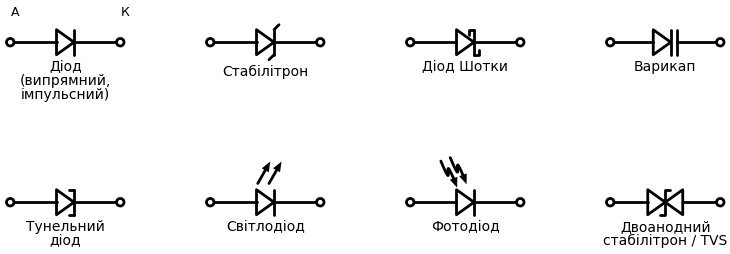

In [2]:
# Умовні графічні позначення діодів (IEC / ДСТУ)
if SCHEMDRAW_AVAILABLE:
    with schemdraw.Drawing(fontsize=11, unit=2.2) as d:
        items = [('Діод\n(випрямний,\nімпульсний)', elm.Diode), ('Стабілітрон', elm.Zener), ('Діод Шотки', elm.Schottky),
                 ('Варикап', elm.Varactor), ('Тунельний\nдіод', elm.DiodeTunnel), ('Світлодіод', elm.LED),
                 ('Фотодіод', elm.Photodiode), ('Двоанодний\nстабілітрон / TVS', elm.DiodeTVS)]
        for k, (name, E) in enumerate(items):
            x = (k % 4)*4.0; y = -(k//4)*3.2
            d.add(E().endpoints((x, y), (x + 2.2, y)).label(name, loc='bottom', fontsize=10))
            d.add(elm.Dot(open=True).at((x, y))); d.add(elm.Dot(open=True).at((x + 2.2, y)))
        d.add(elm.Label().at((0, 0.5)).label('А', fontsize=9)); d.add(elm.Label().at((2.2, 0.5)).label('К', fontsize=9))

Анод (А) — вивід, до якого прикладається «+» при прямому зміщенні; стрілка трикутника показує напрямок прямого струму, риска — катод (К).

---

# Випрямні діоди та випрямлячі <a class="anchor" id="rectifiers"></a>

**Випрямні діоди** перетворюють змінний струм на пульсуючий однополярний. Це площинні p-n діоди (кремнієві, зрідка германієві; для високих напруг і частот — Шотки на SiC) з великою площею переходу; головні параметри — $I_{F(AV)}$, $U_{RRM}$, $I_{FSM}$, пряма напруга $U_{F}$ і час відновлення $t_{rr}$. Приклади: 1N4001–1N4007 (1 А, 50–1000 В), 1N5401–1N5408 (3 А), КД202, Д242 (5–10 А).

**Однопівперіодний випрямляч** — один діод між джерелом і навантаженням: струм тече лише в додатні півперіоди, пульсації великі (частота пульсацій дорівнює частоті мережі $f$).

**Двопівперіодний мостовий випрямляч** (схема Греца) — чотири діоди: у кожен півперіод струм проходить через два діоди, що стоять по діагоналі, і через навантаження — завжди в одному напрямку. Частота пульсацій $2f$, максимальна зворотна напруга на діоді дорівнює амплітуді $U_m$, але на діодах спадає $2U_F$.

**Ємнісний фільтр.** Конденсатор $C$ паралельно навантаженню заряджається до амплітуди ($U_m - U_F$ або $U_m - 2U_F$) і розряджається через $R_н$, коли діоди закриті. При $R_нC \gg 1/f$ розмах пульсацій

$$\Delta U \approx \frac{I_н}{f_п\,C}, \qquad f_п = f \;(\text{однопівперіодний}),\; 2f \;(\text{мостовий}).$$

Ціна фільтрації — **імпульсний** струм діодів: конденсатор підзаряджається лише за короткий проміжок біля вершини синусоїди, тому пікові струми діодів у кілька разів перевищують струм навантаження.

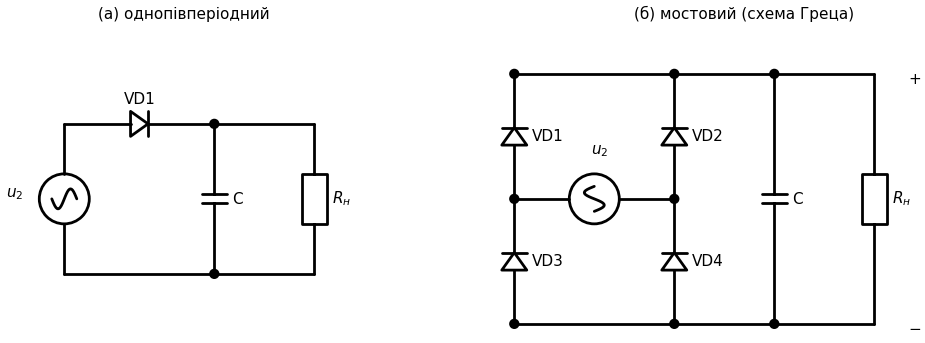

In [3]:
# Схеми однопівперіодного та мостового випрямлячів з ємнісним фільтром
if SCHEMDRAW_AVAILABLE:
    with schemdraw.Drawing(fontsize=11, unit=2.5) as d:
        # (а) однопівперіодний
        d.add(elm.SourceSin().endpoints((0, 0), (0, 3))); d.add(elm.Label().at((-0.9, 1.5)).label('$u_2$'))
        d.add(elm.Diode().endpoints((0, 3), (3, 3)).label('VD1'))
        d.add(elm.Dot().at((3, 3))); d.add(elm.Capacitor().endpoints((3, 3), (3, 0)).label('C', loc='bottom'))
        d.add(elm.Line().endpoints((3, 3), (5, 3))); d.add(elm.Resistor().endpoints((5, 3), (5, 0)).label('$R_н$', loc='bottom'))
        d.add(elm.Line().endpoints((5, 0), (0, 0))); d.add(elm.Dot().at((3, 0)))
        d.add(elm.Label().at((2.5, 5.3)).label('(а) однопівперіодний'))
        # (б) мостовий: верхня шина «+», нижня «−», дві вертикальні гілки; обмотка — у середній «перекладині»
        X = 9; W = 3.2
        d.add(elm.Line().endpoints((X, 4), (X + W + 2, 4))); d.add(elm.Line().endpoints((X, -1), (X + W + 2, -1)))
        for xc, lab_up, lab_dn in [(X, 'VD1', 'VD3'), (X + W, 'VD2', 'VD4')]:
            d.add(elm.Diode().endpoints((xc, 1.5), (xc, 4)).label(lab_up, loc='bottom'))     # анод — середина, катод — «+»
            d.add(elm.Diode().endpoints((xc, -1), (xc, 1.5)).label(lab_dn, loc='bottom'))    # анод — «−», катод — середина
            d.add(elm.Dot().at((xc, 1.5))); d.add(elm.Dot().at((xc, 4))); d.add(elm.Dot().at((xc, -1)))
        d.add(elm.SourceSin().endpoints((X, 1.5), (X + W, 1.5)))
        d.add(elm.Label().at((X + W/2, 2.35)).label('$u_2$'))
        d.add(elm.Capacitor().endpoints((X + W + 2, 4), (X + W + 2, -1)).label('C', loc='bottom'))
        d.add(elm.Dot().at((X + W + 2, 4))); d.add(elm.Dot().at((X + W + 2, -1)))
        d.add(elm.Line().endpoints((X + W + 2, 4), (X + W + 4, 4))); d.add(elm.Line().endpoints((X + W + 2, -1), (X + W + 4, -1)))
        d.add(elm.Resistor().endpoints((X + W + 4, 4), (X + W + 4, -1)).label('$R_н$', loc='bottom'))
        d.add(elm.Label().at((X + W + 4.7, 4)).label('+')); d.add(elm.Label().at((X + W + 4.7, -1)).label('−'))
        d.add(elm.Label().at((X + 4.5, 5.3)).label('(б) мостовий (схема Греца)'))

### ⚙️ PySpice: випрямляч з ємнісним фільтром <a class="anchor" id="spice-rectifier"></a>

Вторинна обмотка трансформатора — синусоїда 12 В (діюче значення), 50 Гц, з активним опором обмотки 0,5 Ом; діоди 1N4007. Змінюйте ємність фільтра й опір навантаження, порівняйте однопівперіодну і мостову схеми. Зверніть увагу на **піковий струм діодів** і на перший (пусковий) імпульс заряду конденсатора.

In [4]:
def rectifier(scheme='мостовий', C_uF=1000, R_load=100):
    Um, f = 12*np.sqrt(2), 50.0
    c = Circuit('Rectifier')
    c.include(lib('diodes'))
    c.SinusoidalVoltageSource('s', 'u', 'w', amplitude=Um, frequency=f)
    c.R('w', 'w', 'b', 0.5)                                    # опір обмотки
    if scheme == 'мостовий':
        c.D('1', 'u', 'p', model='DI_1N4007'); c.D('2', 'b', 'p', model='DI_1N4007')
        c.D('3', c.gnd, 'u', model='DI_1N4007'); c.D('4', c.gnd, 'b', model='DI_1N4007')
        c.R('f1', 'u', c.gnd, 10e6); c.R('f2', 'b', c.gnd, 10e6)   # щоб вузли обмотки не «висіли» при закритих діодах
    else:
        c.R('gnd', 'b', c.gnd, 1e-3)
        c.D('1', 'u', 'p', model='DI_1N4007')
    c.C('f', 'p', c.gnd, C_uF*1e-6)
    c.R('n', 'p', c.gnd, R_load)
    an = c.simulator().transient(step_time=20e-6, end_time=0.12, max_time=50e-6)
    t = np.array(an.time)*1e3
    u2 = np.array(an['u']) - np.array(an['b'])
    uo = np.array(an['p'])
    iD1 = np.array(an.branches['vs'])*(-1) if False else None
    # струм вторинної обмотки = струм через опір обмотки
    i_w = (np.array(an['w']) - np.array(an['b']))/0.5
    fig, axes = plt.subplots(2, 1, figsize=(10, 6.2), sharex=True)
    axes[0].plot(t, u2, color='gray', lw=1, label='$u_2$ (обмотка)')
    axes[0].plot(t, uo, color='#dc2626', lw=2, label='$u_{вих}$ (навантаження)')
    axes[0].set_ylabel('U, В'); axes[0].legend(fontsize=9, loc='lower right'); axes[0].set_title(f'{scheme} випрямляч, C = {C_uF} мкФ, $R_н$ = {R_load} Ом')
    axes[1].plot(t, -i_w, color='#2563eb', lw=1.5, label='струм обмотки (= струм діодів)')
    axes[1].plot(t, uo/R_load, color='#dc2626', lw=1.5, label='струм навантаження')
    axes[1].set_ylabel('I, А'); axes[1].set_xlabel('t, мс'); axes[1].legend(fontsize=9, loc='upper right')
    plt.tight_layout(); plt.show()
    m = t > 80
    U0, dU = uo[m].mean(), uo[m].max() - uo[m].min()
    fp = 2*f if scheme == 'мостовий' else f
    print(f'Постійна складова U0 = {U0:.2f} В;  розмах пульсацій ΔU = {dU:.2f} В (оцінка Iн/(fп·C) = {U0/R_load/(fp*C_uF*1e-6):.2f} В)')
    print(f'Струм навантаження {U0/R_load*1e3:.0f} мА;  піковий струм діодів в усталеному режимі {np.max(np.abs(i_w[m]))*1e3:.0f} мА;'
          f'  пусковий імпульс {np.max(np.abs(i_w))*1e3:.0f} мА')

interact(rectifier, scheme=widgets.ToggleButtons(options=['мостовий', 'однопівперіодний'], description='Схема'),
         C_uF=widgets.SelectionSlider(options=[10, 47, 100, 220, 470, 1000, 2200, 4700], value=1000, description='C, мкФ',
                                      continuous_update=False),
         R_load=widgets.IntSlider(min=20, max=1000, step=10, value=100, description='$R_н$, Ом', continuous_update=False));

interactive(children=(ToggleButtons(description='Схема', options=('мостовий', 'однопівперіодний'), value='мост…

---

# Послідовне та паралельне з'єднання діодів <a class="anchor" id="series-parallel"></a>

**Паралельне з'єднання** застосовують, коли струм навантаження перевищує $I_{F(AV)}$ одного діода. Через експоненційну ВАХ навіть малий розкид параметрів спричиняє **нерівномірний розподіл струму**: діод з удвічі більшим $I_S$ при тій самій напрузі проводить удвічі більший струм. До того ж ТКН прямої напруги від'ємний: діод, що нагрівся сильніше, «відбирає» ще більше струму (додатний тепловий зворотний зв'язок). Для вирівнювання послідовно з кожним діодом вмикають **вирівнювальні резистори** $R_в$ (спад на них порядку 0,1–0,5 В), підбирають діоди з однієї партії і ставлять їх на спільний тепловідвід.

**Послідовне з'єднання** застосовують, коли зворотна напруга перевищує $U_{RRM}$ одного діода. Тепер небезпечний розкид **зворотних струмів**: закриті діоди — це послідовний ланцюг великих опорів, і найбільша частина напруги падає на діоді з **найменшим** зворотним струмом. Він пробивається першим, після чого напруга перерозподіляється на решту — лавиноподібна відмова. Для статичного вирівнювання паралельно кожному діоду вмикають **шунтувальні резистори** $R_ш$ (струм через них у 5–10 разів більший за зворотний струм діода), для динамічного — **конденсатори** $C_ш$, які вирівнюють напругу під час перемикання, коли діоди мають різний $t_{rr}$. Промислові високовольтні **випрямні стовпи** (КЦ106, 2CL, HV-діоди мікрохвильових печей) містять десятки послідовних кристалів в одному корпусі.

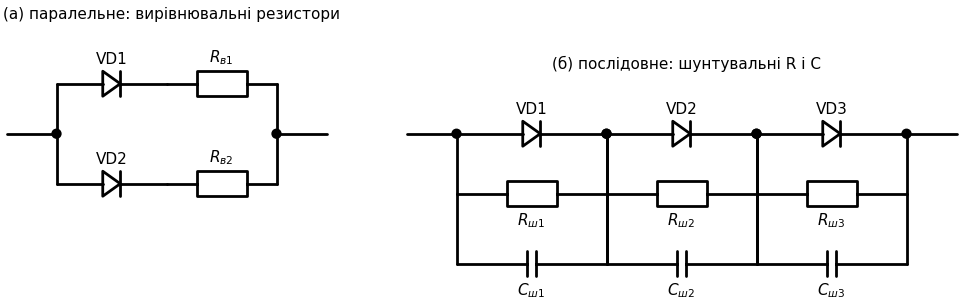

In [5]:
if SCHEMDRAW_AVAILABLE:
    with schemdraw.Drawing(fontsize=11, unit=2) as d:
        # (а) паралельне
        for y, k in [(2.0, 1), (0.0, 2)]:
            d.add(elm.Diode().endpoints((1, y), (3.2, y)).label(f'VD{k}'))
            d.add(elm.Resistor().endpoints((3.2, y), (5.4, y)).label(f'$R_{{в{k}}}$'))
        d.add(elm.Line().endpoints((1, 2), (1, 0))); d.add(elm.Line().endpoints((5.4, 2), (5.4, 0)))
        d.add(elm.Line().endpoints((0, 1), (1, 1))); d.add(elm.Line().endpoints((5.4, 1), (6.4, 1)))
        d.add(elm.Dot().at((1, 1))); d.add(elm.Dot().at((5.4, 1)))
        d.add(elm.Label().at((3.2, 3.3)).label('(а) паралельне: вирівнювальні резистори'))
        # (б) послідовне
        X = 9
        for k in range(3):
            x0 = X + k*3.0
            d.add(elm.Diode().endpoints((x0, 1), (x0 + 3.0, 1)).label(f'VD{k+1}'))
            d.add(elm.Dot().at((x0, 1))); d.add(elm.Dot().at((x0 + 3.0, 1)))
            d.add(elm.Line().endpoints((x0, 1), (x0, -0.2))); d.add(elm.Line().endpoints((x0 + 3.0, 1), (x0 + 3.0, -0.2)))
            d.add(elm.Resistor().endpoints((x0, -0.2), (x0 + 3.0, -0.2)).label(f'$R_{{ш{k+1}}}$', loc='bottom'))
            d.add(elm.Line().endpoints((x0, -0.2), (x0, -1.6))); d.add(elm.Line().endpoints((x0 + 3.0, -0.2), (x0 + 3.0, -1.6)))
            d.add(elm.Capacitor().endpoints((x0, -1.6), (x0 + 3.0, -1.6)).label(f'$C_{{ш{k+1}}}$', loc='bottom'))
        d.add(elm.Line().endpoints((X - 1, 1), (X, 1))); d.add(elm.Line().endpoints((X + 9, 1), (X + 10, 1)))
        d.add(elm.Label().at((X + 4.5, 2.3)).label('(б) послідовне: шунтувальні R і C'))

### ⚙️ PySpice: розподіл струму і напруги між діодами <a class="anchor" id="spice-sharing"></a>

**Паралельне з'єднання:** два діоди 1N4007, у другого струм насичення в $k$ разів більший (розкид параметрів або вищий нагрів); загальний струм 2 А. **Послідовне з'єднання:** два діоди на 1000 В під зворотною напругою 1600 В; їхні зворотні струми відрізняються (моделюються опорами витоку 1000 МОм і 200 МОм).

In [6]:
def sharing(mode='паралельне', mismatch=2.0, R_eq=0.0):
    c = Circuit('Sharing'); c.include(lib('diodes'))
    if mode == 'паралельне':
        c.model('D_hot', 'D', IS=76.9e-12*mismatch, RS=42e-3, N=1.45, BV=1000, IBV=5e-6, CJO=26.5e-12, M=0.333, TT=4.32e-6)
        c.I('tot', c.gnd, 'a', 2.0)
        c.D('1', 'a', 'k1', model='DI_1N4007'); c.D('2', 'a', 'k2', model='D_hot')
        c.R('1', 'k1', c.gnd, max(R_eq, 1e-6)); c.R('2', 'k2', c.gnd, max(R_eq, 1e-6))
        op = c.simulator().operating_point()
        i1 = float(op['k1'][0])/max(R_eq, 1e-6); i2 = float(op['k2'][0])/max(R_eq, 1e-6)
        if R_eq == 0:   # без резисторів — струми з різниці потенціалів неможливо взяти, рахуємо за моделлю
            U = float(op['a'][0])
            Vt = phi_T(300.15); n = 1.45
            f = lambda Is, I: I - Is*(np.exp((U - I*42e-3)/(n*Vt)) - 1)
            from scipy.optimize import brentq
            i1 = brentq(lambda I: f(76.9e-12, I), 0, 2.1); i2 = brentq(lambda I: f(76.9e-12*mismatch, I), 0, 2.1)
        fig, ax = plt.subplots(figsize=(6.5, 3.8))
        ax.bar(['VD1 (номінальний)', f'VD2 ($I_S$ × {mismatch:g})'], [i1, i2], color=['#2563eb', '#dc2626'])
        ax.axhline(1.0, color='k', ls='--', lw=1); ax.text(-0.45, 1.03, 'рівний поділ', fontsize=9)
        ax.set_ylabel('струм, А'); ax.set_ylim(0, 2.1); ax.set_title(f'Паралельне з\'єднання, $R_в$ = {R_eq:g} Ом')
        plt.tight_layout(); plt.show()
        print(f'I1 = {i1:.3f} A, I2 = {i2:.3f} A;  нерівномірність I2/I1 = {i2/i1:.2f}')
    else:
        c.V('r', c.gnd, 'top', 1600)                                  # «+» на катоді верхнього → зворотне зміщення
        c.D('1', 'top', 'mid', model='DI_1N4007'); c.D('2', 'mid', c.gnd, model='DI_1N4007')
        c.R('lk1', 'top', 'mid', 1000e6); c.R('lk2', 'mid', c.gnd, 1000e6/mismatch)   # витоки (зворотні струми)
        if R_eq > 0:
            c.R('sh1', 'top', 'mid', R_eq*1e6); c.R('sh2', 'mid', c.gnd, R_eq*1e6)
        op = c.simulator().operating_point()
        U2 = -float(op['mid'][0]); U1 = 1600 - U2
        fig, ax = plt.subplots(figsize=(6.5, 3.8))
        ax.bar(['VD1 (малий витік)', f'VD2 (витік × {mismatch:g})'], [U1, U2], color=['#2563eb', '#dc2626'])
        ax.axhline(1000, color='r', ls='--', lw=1); ax.text(1.45, 1020, '$U_{RRM}$ = 1000 В', ha='right', fontsize=9, color='r')
        ax.set_ylabel('зворотна напруга, В'); ax.set_ylim(0, 1700)
        ax.set_title('Послідовне з\'єднання, ' + (f'$R_ш$ = {R_eq:g} МОм' if R_eq else 'без шунтів'))
        plt.tight_layout(); plt.show()
        print(f'U1 = {U1:.0f} В, U2 = {U2:.0f} В  →  ' + ('ПЕРЕВИЩЕННЯ U_RRM!' if max(U1, U2) > 1000 else 'обидва в межах 1000 В'))

interact(sharing, mode=widgets.ToggleButtons(options=['паралельне', 'послідовне'], description='З\'єднання'),
         mismatch=widgets.FloatSlider(min=1, max=5, step=0.5, value=2, description='розкид ×', continuous_update=False),
         R_eq=widgets.SelectionSlider(options=[0, 0.05, 0.1, 0.2, 0.5, 1, 2, 5, 10], value=0,
                                      description='$R_в$ (Ом) / $R_ш$ (МОм)', style={'description_width': 'initial'},
                                      continuous_update=False));

interactive(children=(ToggleButtons(description="З'єднання", options=('паралельне', 'послідовне'), value='пара…

---

# Діоди Шотки <a class="anchor" id="schottky"></a>

**Діод Шотки** використовує випрямний контакт метал–напівпровідник (Лекція 2). Струм переносять **основні** носії, які долають бар'єр $\varphi_B$ завдяки термоелектронній емісії:

$$I = S A^* T^2 e^{-\varphi_B/\varphi_T}\left(e^{U/n\varphi_T} - 1\right),$$

де $A^* \approx 110$ А/(см²·К²) для n-Si — стала Річардсона. Оскільки $\varphi_B$ (0,5–0,8 В) менший за $E_g$ і «струм насичення» на кілька порядків більший, ніж у p-n діода, **пряма напруга нижча**: 0,2–0,45 В замість 0,6–1 В.

| Переваги | Недоліки |
|---|---|
| Мала пряма напруга → менші втрати ($P = U_FI$) | Великий зворотний струм, що швидко зростає з температурою |
| Немає накопичення неосновних носіїв → $t_{rr} \approx 0$, висока швидкодія | Невисока допустима зворотна напруга (кремній: до 100–200 В) |
| Малий рівень комутаційних завад | Чутливість до перегріву і перенапруг |

Застосування: вихідні випрямлячі імпульсних джерел живлення, захисні та «ORing»-діоди в колах живлення, детектори і змішувачі НВЧ, антинасичувальні ланцюги в логіці Шотки-ТТЛ (серії 74S, 74LS). На **карбіді кремнію** (SiC) виготовляють діоди Шотки на 600–1700 В для потужних перетворювачів.

### ⚙️ PySpice: діод Шотки проти p-n діода <a class="anchor" id="spice-schottky"></a>

Порівнюємо діод Шотки **1N5819** (40 В, 1 А) і p-n діод **1N4007** (1000 В, 1 А) — прилади одного класу струму.

In [7]:
def dc_curve(model, U0, U1, step, T=27, reverse=False):
    c = Circuit('dc'); c.include(lib('diodes'))
    c.V('d', 'a', c.gnd, 0)
    if reverse: c.D('1', c.gnd, 'a', model=model)
    else: c.D('1', 'a', c.gnd, model=model)
    an = c.simulator(temperature=T, nominal_temperature=27).dc(Vd=slice(U0, U1, step))
    return np.array(an.sweep), -np.array(an.branches['vd'])

def schottky_cmp(T=27):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
    for m, lab, col in [('D1N5819', '1N5819 (Шотки)', '#dc2626'), ('DI_1N4007', '1N4007 (p-n)', '#2563eb')]:
        U, I = dc_curve(m, 0, 1.1, 0.002, T)
        axes[0].semilogy(U, np.clip(I, 1e-12, None), color=col, label=lab)
        Ur, Ir = dc_curve(m, 0, 40, 0.2, T, reverse=True)
        axes[1].semilogy(Ur, np.clip(Ir, 1e-13, None), color=col, label=lab)
        k = np.argmin(abs(I - 1.0))
        print(f'{lab:16s}: U_F(1 А) = {U[k]:.3f} В → втрати {U[k]:.2f} Вт;  I_зв(30 В) = {Ir[np.argmin(abs(Ur-30))]*1e6:.3g} мкА')
    axes[0].set_ylim(1e-9, 3); axes[0].set_xlabel('U, В'); axes[0].set_ylabel('I, А'); axes[0].set_title(f'Пряма гілка, T = {T} °C')
    axes[1].set_xlabel('зворотна напруга, В'); axes[1].set_ylabel('зворотний струм, А'); axes[1].set_title(f'Зворотна гілка, T = {T} °C')
    for a in axes: a.legend(fontsize=9); a.grid(True, which='both', alpha=0.3)
    plt.tight_layout(); plt.show()

interact(schottky_cmp, T=widgets.IntSlider(min=-25, max=125, step=25, value=27, description='T, °C', continuous_update=False));

interactive(children=(IntSlider(value=27, continuous_update=False, description='T, °C', max=125, min=-25, step…

---
### ⚠️ Типова помилка

<div style="background-color: #fef2f2; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #dc2626; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

SPICE-модель 1N5819 не враховує зниження бар'єра Шотки полем сил зображення, тому її зворотний струм майже не залежить від напруги. У реальних діодах Шотки він помітно зростає з $|U|$. Температурна залежність (повзунок T) відтворюється правильно.

Діод Шотки — **не** «швидкий p-n діод». У нього немає p-n переходу й інжекції неосновних носіїв; швидкодію обмежує лише бар'єрна ємність контакту. З тієї самої причини великий зворотний струм діода Шотки — не дефект, а наслідок низького бар'єра. При 100 °C зворотний струм 1N5819 сягає міліамперів, і в щільно скомпонованих джерелах живлення це може спричинити тепловий пробій.

</div>

---

# Стабілітрони <a class="anchor" id="zener"></a>

**Стабілітрон** — діод, робочою ділянкою якого є **зворотна гілка в режимі електричного пробою**. Технологія (точне легування, рівномірний перехід, запас за потужністю) забезпечує оборотність пробою: поки струм і потужність не перевищують допустимих, стабілітрон працює як завгодно довго. На ділянці пробою напруга майже не залежить від струму — прилад тримає $U_{ст}$.

**Основні параметри:** напруга стабілізації $U_{ст}$ (від 1,8 до 200 В; ряд E24) при струмі $I_{ст}$; мінімальний струм $I_{ст.min}$ (нижче «коліна» стабілізація погана); максимальний $I_{ст.max} = P_{max}/U_{ст}$; **диференціальний опір** $r_{ст} = dU/dI$ (одиниці–десятки Ом, найменший у стабілітронів на 6–8 В); **ТКН** — від'ємний для $U_{ст} < 5$ В (тунельний пробій), додатний для $U_{ст} > 6$ В (лавинний), близький до нуля при 5,6–6,2 В.

**Різновиди:** прецизійні (термокомпенсовані — послідовно зі стабілітроном вмикають прямозміщені діоди з від'ємним ТКН, наприклад Д818, 1N821–1N829); **двоанодні** (симетричні) — для обмеження змінних напруг; **стабістори** — прямозміщені діоди для стабілізації 0,7–2 В; **інтегральні джерела опорної напруги** (TL431, LM385) — «керовані стабілітрони» з $r_{ст}$ ≈ 0,2 Ом і ТКН ≈ 30 ppm/°C.

**Параметричний стабілізатор** — стабілітрон паралельно навантаженню й баластний резистор $R_б$ послідовно з джерелом:

$$R_б = \frac{E_{min} - U_{ст}}{I_{ст.min} + I_{н.max}}, \qquad K_{ст} = \frac{\Delta E/E}{\Delta U_{вих}/U_{вих}} \approx \frac{R_б}{r_{ст}}\cdot\frac{U_{вих}}{E}.$$

При зростанні $E$ надлишок напруги падає на $R_б$, а надлишок струму «забирає» стабілітрон; при зменшенні струму навантаження стабілітрон бере на себе більший струм — і навпаки.

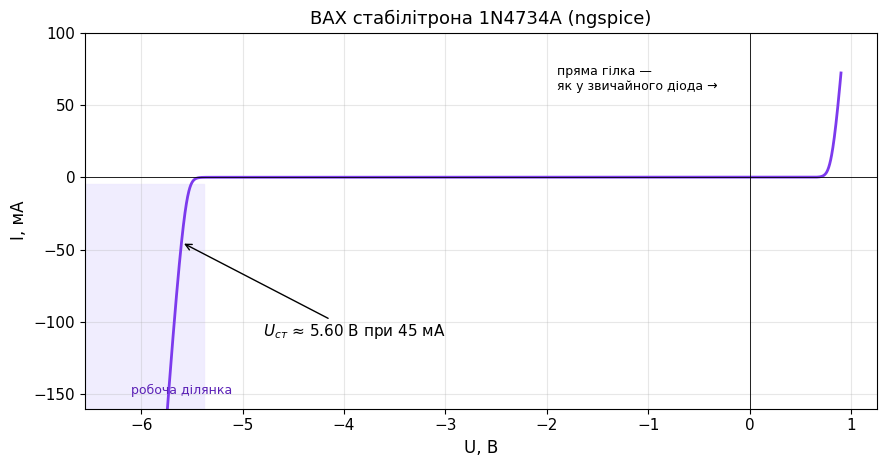

Диференціальний опір на ділянці 10–100 мА: r_ст ≈ 1.58 Ом (паспорт: ≤ 2 Ом при 45 мА)


In [8]:
# ВАХ стабілітрона 1N4734A (5,6 В, 1 Вт) — ngspice
U, I = dc_curve('D1N4734', -6.2, 0.9, 0.002)
fig, ax = plt.subplots(figsize=(9, 4.8))
ax.plot(U, I*1e3, color='#7c3aed')
ax.axhline(0, color='k', lw=0.6); ax.axvline(0, color='k', lw=0.6)
ax.set_ylim(-160, 100); ax.set_xlabel('U, В'); ax.set_ylabel('I, мА')
k1, k2 = np.argmin(abs(I + 0.01)), np.argmin(abs(I + 0.1))
rz = (U[k1] - U[k2])/(0.1 - 0.01)
ax.annotate(f'$U_{{ст}}$ ≈ {-U[np.argmin(abs(I + 0.045))]:.2f} В при 45 мА', xy=(U[np.argmin(abs(I + 0.045))], -45), xytext=(-4.8, -110),
            arrowprops=dict(arrowstyle='->'))
ax.axhspan(-160, -5, xmin=0, xmax=0.15, color='#ede9fe', alpha=0.8)
ax.text(-6.1, -150, 'робоча ділянка', fontsize=9, color='#5b21b6')
ax.text(-1.9, 60, 'пряма гілка —\nяк у звичайного діода →', fontsize=9)
ax.set_title('ВАХ стабілітрона 1N4734A (ngspice)')
plt.tight_layout(); plt.show()
print(f'Диференціальний опір на ділянці 10–100 мА: r_ст ≈ {rz:.2f} Ом (паспорт: ≤ 2 Ом при 45 мА)')

### ⚙️ PySpice: параметричний стабілізатор напруги <a class="anchor" id="spice-zener"></a>

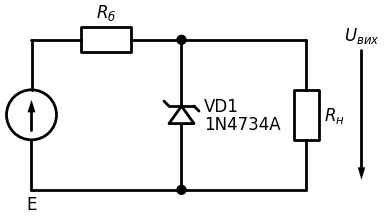

In [9]:
if SCHEMDRAW_AVAILABLE:
    with schemdraw.Drawing(fontsize=12, unit=2.5) as d:
        d.add(EMF().endpoints((0, 0), (0, 3)).label('E', loc='left'))
        d.add(elm.Resistor().endpoints((0, 3), (3, 3)).label('$R_б$'))
        d.add(elm.Dot().at((3, 3)))
        d.add(elm.Zener().endpoints((3, 0), (3, 3)).label('VD1\n1N4734A', loc='bottom'))   # анод — внизу, катод — до «+»
        d.add(elm.Line().endpoints((3, 3), (5.5, 3))); d.add(elm.Resistor().endpoints((5.5, 3), (5.5, 0)).label('$R_н$', loc='bottom'))
        d.add(elm.Line().endpoints((5.5, 0), (0, 0))); d.add(elm.Dot().at((3, 0)))
        d.add(elm.Arrow().endpoints((6.6, 2.8), (6.6, 0.2)).label('$U_{вих}$', loc='right'))

In [10]:
def zener_reg(Rb=100, R_load=470, E_nom=12.0):
    def op(E, Rn):
        c = Circuit('Zener shunt regulator'); c.include(lib('diodes'))
        c.V('e', 'e', c.gnd, E); c.R('b', 'e', 'o', Rb)
        c.D('z', c.gnd, 'o', model='D1N4734')           # анод — земля, катод — вихід (зворотне ввімкнення)
        c.R('n', 'o', c.gnd, Rn)
        return c
    c = op(E_nom, R_load)
    an = c.simulator().dc(Ve=slice(0, 20, 0.05))
    E = np.array(an.sweep); Uo = np.array(an['o'])
    Iz = (E - Uo)/Rb - Uo/R_load
    Rn_list = np.linspace(20, 2000, 100); Uo_n = []
    for Rn in Rn_list:
        Uo_n.append(float(op(E_nom, Rn).simulator().operating_point()['o'][0]))
    Uo_n = np.array(Uo_n)
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))
    axes[0].plot(E, Uo, color='#7c3aed'); axes[0].plot(E, E*R_load/(R_load + Rb), ':', color='gray', lw=1, label='без стабілітрона')
    axes[0].axvline(E_nom, color='gray', ls='--', lw=1); axes[0].set_xlabel('E, В'); axes[0].set_ylabel('$U_{вих}$, В')
    axes[0].set_title('Стабілізація при зміні вхідної напруги'); axes[0].legend(fontsize=9); axes[0].set_ylim(0, 10)
    axes[1].plot(E, Iz*1e3, color='#dc2626'); axes[1].axhline(5, color='gray', ls=':', lw=1)
    axes[1].axhline(1000/5.6, color='r', ls='--', lw=1); axes[1].text(0.5, 1000/5.6 + 5, '$I_{ст.max}$ = P/U = 178 мА', fontsize=8, color='r')
    axes[1].text(0.5, 8, '$I_{ст.min}$ ≈ 5 мА', fontsize=8, color='gray')
    axes[1].set_xlabel('E, В'); axes[1].set_ylabel('$I_{ст}$, мА'); axes[1].set_title('Струм стабілітрона')
    axes[2].plot(Uo_n/Rn_list*1e3, Uo_n, color='#16a34a')
    axes[2].set_xlabel('$I_н$, мА'); axes[2].set_ylabel('$U_{вих}$, В'); axes[2].set_title(f'Навантажувальна характеристика (E = {E_nom} В)')
    axes[2].set_ylim(0, 7)
    plt.tight_layout(); plt.show()
    k = np.argmin(abs(E - E_nom)); k1, k2 = np.argmin(abs(E - 0.9*E_nom)), np.argmin(abs(E - 1.1*E_nom))
    Kst = (0.2)/((Uo[k2] - Uo[k1])/Uo[k])
    print(f'E = {E_nom} В: U_вих = {Uo[k]:.3f} В, I_ст = {Iz[k]*1e3:.1f} мА, P_ст = {Iz[k]*Uo[k]*1e3:.0f} мВт, P_Rб = {(E_nom-Uo[k])**2/Rb*1e3:.0f} мВт')
    print(f'Зміна E на ±10 % змінює U_вих на {(Uo[k2]-Uo[k1])*1e3:.1f} мВ  →  коефіцієнт стабілізації K_ст ≈ {Kst:.0f}')

interact(zener_reg,
         Rb=widgets.IntSlider(min=20, max=500, step=10, value=100, description='$R_б$, Ом', continuous_update=False),
         R_load=widgets.IntSlider(min=20, max=2000, step=10, value=470, description='$R_н$, Ом', continuous_update=False),
         E_nom=widgets.FloatSlider(min=7, max=20, step=0.5, value=12, description='E, В', continuous_update=False));

interactive(children=(IntSlider(value=100, continuous_update=False, description='$R_б$, Ом', max=500, min=20, …

---
### 💡 Цікаво знати

<div style="background-color: #eff6ff; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #2563eb; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

Прецизійні джерела опорної напруги довгий час будували на **термокомпенсованих стабілітронах** з прихованим (підповерхневим) переходом (LM399, LTZ1000). Вони мають дрейф менше 0,05 ppm/°C і шум менше 1 мкВ, тому досі працюють у найточніших 8,5-розрядних мультиметрах. А напругу 6,2 В обрано не випадково: саме там тунельний і лавинний механізми майже компенсують температурні дрейфи один одного.

</div>

---

# Тунельні та обернені діоди <a class="anchor" id="tunnel"></a>

**Тунельний діод** (діод Есакі, 1958) виготовляють з **виродженого** напівпровідника ($N_a, N_d \sim 10^{19}$–$10^{20}$ см⁻³): рівень Фермі лежить усередині дозволених зон — у валентній зоні p-області й у зоні провідності n-області, а ОПЗ має товщину ≈10 нм. Тунелювання можливе і при **прямій** напрузі, поки зайняті стани зони провідності n-області розташовані навпроти вільних станів валентної зони p-області:

1. $U = 0$ — рівні Фермі вирівняні, зустрічні тунельні потоки рівні, $I = 0$;
2. мала пряма напруга — перекриття зайнятих і вільних станів максимальне → **пік** струму $I_п$ при $U_п$ ≈ 50–100 мВ (Ge), 100–150 мВ (GaAs);
3. подальше зростання $U$ — перекриття зменшується, тунельний струм спадає → **ділянка від'ємного диференціального опору** (NDR);
4. $U \approx U_{в}$ (**долина**, 0,3–0,5 В) — перекриття зникає, тече лише надлишковий струм через стани в забороненій зоні;
5. далі — звичайний дифузійний струм p-n переходу.

При зворотній напрузі тунелювання дає великий струм, тобто діод не має запірної гілки. **Обернений діод** — тунельний діод з меншим легуванням, у якого пік майже відсутній: у прямому напрямку він практично не проводить до 0,3–0,5 В, а у зворотному — проводить уже від нуля. Його використовують як детектор і змішувач малих НВЧ-сигналів.

Ділянка від'ємного опору дозволяє будувати на тунельних діодах **генератори й підсилювачі НВЧ** (до сотень ГГц) та надшвидкі перемикачі: сам тунельний ефект не має інерції, обмеження дає лише ємність переходу.

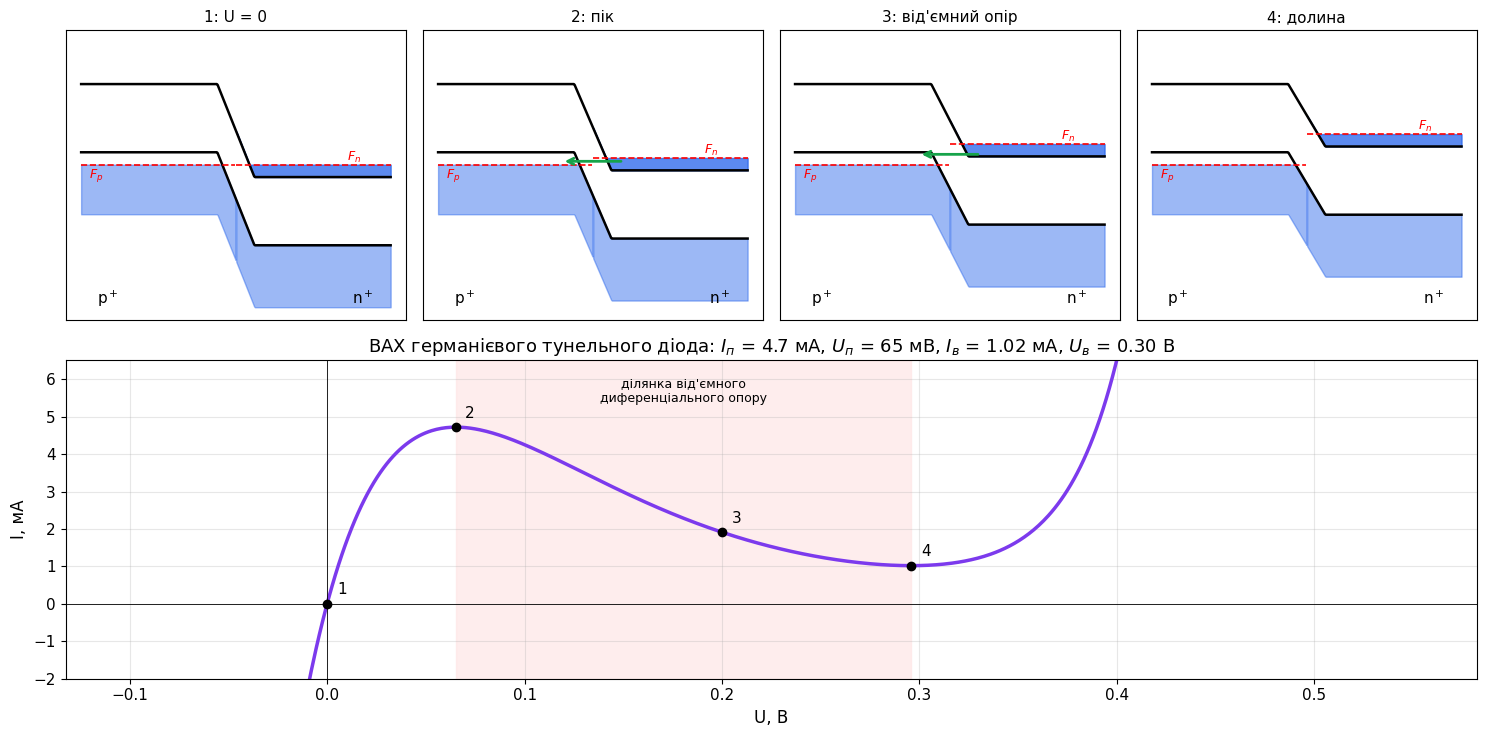

In [11]:
# Зонні діаграми виродженого p+-n+ переходу (тунельний діод) у 4 точках ВАХ і сама ВАХ
Ip, Vp, Iv, Vv, A, Is = 4.7e-3, 0.065, 0.6e-3, 0.35, 12.0, 1e-9
def I_td(v): return Ip*(v/Vp)*np.exp(1 - v/Vp) + Iv*np.exp(A*(v - Vv)) + Is*(np.exp(v/0.02585) - 1)
fig = plt.figure(figsize=(15, 7.5))
gs = fig.add_gridspec(2, 4, height_ratios=[1, 1.1])
Eg, dF = 0.66, 0.12                                          # Ge; рівень Фермі на 0,12 еВ усередині зон
phi_b = Eg + 2*dF                                            # бар'єр рівноважного переходу
vv = np.linspace(0.1, 0.5, 4001); U_valley = vv[np.argmin(I_td(vv))]
pts = [(0.0, '1: U = 0'), (Vp, '2: пік'), (0.20, '3: від\'ємний опір'), (U_valley, '4: долина')]
for k, (U, ttl) in enumerate(pts):
    ax = fig.add_subplot(gs[0, k]); x = np.linspace(-1, 1, 400); w = 0.12
    # p+ (зліва): F_p = 0, рівень Фермі на dF нижче стелі валентної зони -> Ev_p = +dF
    # n+ (справа): F_n = F_p + qU, рівень Фермі на dF вище дна зони провідності -> Ec_n = qU - dF
    s_ = np.clip(0.5 + x/(2*w), 0, 1)                         # 0 у p-області, 1 у n-області
    Ev = dF - (phi_b - U)*s_; Ec = Ev + Eg
    Fp, Fn = 0.0, U
    left, right = x < 0, x > 0
    ax.fill_between(x, np.where(left, Ev - 0.6, np.nan), np.where(left, np.minimum(Ev, Fp), np.nan), color='#2563eb', alpha=0.45)   # зайняті стани ВЗ p
    ax.fill_between(x, np.where(right, Ev - 0.6, np.nan), np.where(right, Ev, np.nan), color='#2563eb', alpha=0.45)  # ВЗ n — заповнена
    ax.fill_between(x, np.where(right, Ec, np.nan), np.where(right, np.maximum(Ec, Fn), np.nan), color='#2563eb', alpha=0.75)  # електрони ЗП n
    ax.plot(x, Ec, 'k', lw=1.8); ax.plot(x, Ev, 'k', lw=1.8)
    ax.plot(x[left], np.full(left.sum(), Fp), 'r--', lw=1.2); ax.plot(x[right], np.full(right.sum(), Fn), 'r--', lw=1.2)
    ax.text(-0.95, Fp - 0.13, '$F_p$', color='r', fontsize=9); ax.text(0.72, Fn + 0.04, '$F_n$', color='r', fontsize=9)
    ax.set_ylim(-1.5, 1.3); ax.set_xticks([]); ax.set_yticks([]); ax.set_title(ttl, fontsize=11)
    ax.text(-0.9, -1.35, 'p$^+$', fontsize=11); ax.text(0.75, -1.35, 'n$^+$', fontsize=11)
    lo, hi = max(U - dF, Fp), min(Fn, dF)                     # перекриття: зайняті стани ЗП n навпроти вільних ВЗ p
    if hi > lo + 1e-3:
        ax.annotate('', xy=(-0.2, (lo + hi)/2), xytext=(0.2, (lo + hi)/2), arrowprops=dict(arrowstyle='->', color='#16a34a', lw=2))
axv = fig.add_subplot(gs[1, :])
v = np.linspace(-0.1, 0.55, 800)
axv.plot(v, I_td(v)*1e3, color='#7c3aed', lw=2.5)
for (U, ttl) in pts:
    axv.plot(U, I_td(np.array(U))*1e3, 'ko'); axv.text(U + 0.005, I_td(np.array(U))*1e3 + 0.25, ttl.split(':')[0], fontsize=11)
axv.axvspan(Vp, U_valley, color='#fee2e2', alpha=0.6); axv.text((Vp + U_valley)/2, 5.4, 'ділянка від\'ємного\nдиференціального опору', ha='center', fontsize=9)
axv.axhline(0, color='k', lw=0.6); axv.axvline(0, color='k', lw=0.6)
axv.set_xlabel('U, В'); axv.set_ylabel('I, мА'); axv.set_ylim(-2, 6.5)
axv.set_title(f'ВАХ германієвого тунельного діода: $I_п$ = {Ip*1e3} мА, $U_п$ = {Vp*1e3:.0f} мВ, $I_в$ = {I_td(U_valley)*1e3:.2f} мА, $U_в$ = {U_valley:.2f} В')
plt.tight_layout(); plt.show()

### ⚙️ PySpice: генератор на тунельному діоді <a class="anchor" id="spice-tunnel"></a>

Тунельний діод описано в ngspice **поведінковим джерелом струму** `B` з наведеною вище ВАХ. Паралельно діоду — конденсатор $C$ = 100 пФ, послідовно з джерелом зміщення — котушка $L$ = 100 нГн і опір $R$ = 5 Ом. Коло збуджується, якщо робоча точка лежить на ділянці від'ємного опору і $|r_{диф}| > R$: від'ємний опір діода компенсує втрати контуру. Змінюйте напругу зміщення на діоді й перевірте, де виникає генерація.

In [12]:
TD_EXPR = f"{Ip}*(v(a)/{Vp})*exp(1-v(a)/{Vp})+{Iv}*exp({A}*(v(a)-{Vv}))+{Is}*(exp(v(a)/0.02585)-1)"

def tunnel_osc(U_bias=0.18):
    Rs, L, C = 5.0, 100e-9, 100e-12
    Vs = U_bias + Rs*I_td(np.array(U_bias))
    c = Circuit('Tunnel diode oscillator')
    c.PulseVoltageSource('b', 'b', c.gnd, initial_value=0, pulsed_value=float(Vs), delay_time=0,
                         rise_time=5e-9, fall_time=5e-9, pulse_width=1, period=2)       # плавне ввімкнення живлення
    c.R('s', 'b', 'm', Rs); c.L('1', 'm', 'a', L); c.C('1', 'a', c.gnd, C)
    c.B('td', 'a', c.gnd, i=TD_EXPR)
    an = c.simulator().transient(step_time=0.02e-9, end_time=300e-9, max_time=0.05e-9)
    t = np.array(an.time)*1e9; va = np.array(an['a']); ia = np.array(an.branches['l1'])
    g = np.gradient(I_td(v), v); r_diff = 1/np.interp(U_bias, v, g)
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
    axes[0].plot(t, va, color='#7c3aed'); axes[0].set_xlabel('t, нс'); axes[0].set_ylabel('$u_{VD}$, В')
    axes[0].set_title(f'Напруга на діоді, $U_{{зм}}$ = {U_bias:.2f} В')
    m = t > 100
    axes[1].plot(v, I_td(v)*1e3, color='gray', lw=1.5, label='ВАХ діода')
    axes[1].plot(va[m], ia[m]*1e3, color='#dc2626', lw=1.2, label='траєкторія (u, i) — граничний цикл')
    axes[1].plot(U_bias, I_td(np.array(U_bias))*1e3, 'ko', label='робоча точка')
    axes[1].set_xlabel('u, В'); axes[1].set_ylabel('i, мА'); axes[1].set_xlim(-0.1, 0.55); axes[1].set_ylim(min(-2, ia[m].min()*1e3 - 1), max(8, ia[m].max()*1e3 + 1)); axes[1].legend(fontsize=9, loc='upper right')
    axes[1].set_title('Фазова площина')
    plt.tight_layout(); plt.show()
    x = va[m] - va[m].mean(); zc = np.where(np.diff(np.sign(x)) > 0)[0]
    osc = (va[m].max() - va[m].min()) > 0.02
    print(f'Диференціальний опір діода в робочій точці: r = {r_diff:.0f} Ом')
    if osc and len(zc) > 2:
        f = (len(zc) - 1)/((t[m][zc[-1]] - t[m][zc[0]])*1e-9)
        print(f'Генерація є: f ≈ {f/1e6:.1f} МГц (резонанс LC: {1/(2*np.pi*np.sqrt(L*C))/1e6:.1f} МГц), розмах {va[m].max()-va[m].min():.2f} В')
    else:
        print('Генерації немає: робоча точка поза ділянкою від\'ємного опору (r > 0)')

interact(tunnel_osc, U_bias=widgets.FloatSlider(min=0.02, max=0.45, step=0.01, value=0.18, description='$U_{зм}$, В',
                                                continuous_update=False));

interactive(children=(FloatSlider(value=0.18, continuous_update=False, description='$U_{зм}$, В', max=0.45, mi…

---

# Діоди спеціального призначення <a class="anchor" id="special-diodes"></a>

| Тип | Принцип | Застосування |
|---|---|---|
| **Імпульсні** (1N4148, КД522) | Мала площа, легування золотом → $t_{rr}$ = 1–4 нс, $C$ ≈ 1–4 пФ | Логічні схеми, ключі, детектори |
| **Супресори (TVS)** | Лавинний пробій при великій площі переходу; поглинають імпульси до кВт за 1 мс | Захист входів і шин живлення від перенапруг, ESD |
| **p-i-n діоди** | Широкий власний i-шар; опір на НВЧ керується прямим струмом | Атенюатори, перемикачі НВЧ, фотодіоди |
| **Діоди Ганна** | Об'ємний ефект у GaAs/InP (без p-n переходу): від'ємна диференційна рухливість електронів | НВЧ-генератори 5–100 ГГц |
| **Лавинно-пролітні (IMPATT)** | Лавинне множення + прольотна затримка → від'ємний опір | Потужні НВЧ-генератори до 300 ГГц |
| **Стабістори** | Пряма гілка кількох послідовних переходів | Стабілізація 0,7–2 В |
| **Діоди Шотки на SiC** | Бар'єр Шотки на широкозонному карбіді кремнію | Коректори коефіцієнта потужності, інвертори 600–1700 В |

---
### ⚡ Практичне застосування: Діодні обмежувачі та захист входів

<div style="background-color: #fffbeb; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #f59e0b; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

Два діоди від входу мікросхеми до шин живлення ($+U_{живл}$ і землі) відкриваються, щойно вхідна напруга виходить за межі живлення більше ніж на ~0,6 В, і відводять енергію завади. Такі ланцюги вбудовані в кожен вивід КМОН-мікросхем. Для захисту від ESD і імпульсних перенапруг на лініях USB, Ethernet, CAN використовують **TVS-діоди** (супресори) з малою ємністю. Стабілітрон паралельно входу вимірювального приладу обмежує напругу на безпечному рівні, а діод Шотки послідовно з батареєю захищає від її неправильного підключення з мінімальними втратами.

</div>

---
### ✅ Питання для самоперевірки: Діоди та їх застосування

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 1.</b> Чому в мостовому випрямлячі на кожному діоді максимальна зворотна напруга дорівнює амплітуді $U_m$, а не $2U_m$?</summary>

> **Відповідь:** У кожен півперіод закриті діоди підключені паралельно до обмотки через відкриті діоди (спад на яких малий), тому до них прикладена саме напруга обмотки, тобто не більше за $U_m$. У двопівперіодній схемі з середньою точкою — $2U_m$.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 2.</b> Чому збільшення ємності фільтра випрямляча збільшує піковий струм діодів?</summary>

> **Відповідь:** Пульсації зменшуються, і конденсатор підзаряджається лише за короткий час біля вершини синусоїди. Той самий заряд, що витрачається навантаженням за період, переноситься за коротший проміжок, тож струм діодів більший. Великий $C$ також збільшує пусковий кидок струму.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 3.</b> Чому при послідовному з'єднанні діодів найбільшу напругу отримує діод з найменшим зворотним струмом?</summary>

> **Відповідь:** Закриті діоди — послідовне коло з однаковим струмом. Діод з меншим зворотним струмом має більший еквівалентний опір, і на ньому падає більша частина напруги.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 4.</b> Як зміниться вихідна напруга параметричного стабілізатора, якщо відключити навантаження?</summary>

> **Відповідь:** Практично не зміниться: весь струм через $R_б$ піде в стабілітрон, і напруга зросте лише на $\Delta I\cdot r_{ст}$. Але потужність, яка розсіюється стабілітроном, стане максимальною — це треба враховувати при виборі $P_{max}$.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 5.</b> Чому тунельний діод не можна використовувати як випрямляч?</summary>

> **Відповідь:** Через вироджене легування тунельний струм великий і при зворотній напрузі — у діода немає запірної гілки. Він проводить в обох напрямках, а на прямій гілці має ділянку від'ємного опору.

</details>

---
### 📝 Задачі для самостійного розв'язання: Діоди та їх застосування


<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 1.** Мостовий випрямляч живиться від обмотки 12 В (діюче значення, 50 Гц); пряма напруга кожного діода 0,85 В; $R_н = 100$ Ом, $C = 2200$ мкФ. Оцініть максимальну вихідну напругу, струм навантаження і розмах пульсацій.

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> $U_m = 12\sqrt2 = 16{,}97$ В; $U_{вих.max} = U_m - 2U_F = 15{,}27$ В; $I_н \approx 153$ мА; $\Delta U \approx I_н/(2fC) = 0{,}153/(100\cdot2{,}2\cdot10^{-3}) \approx 0{,}69$ В.

</details>


<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 2.** Параметричний стабілізатор: $E = 12$ В ± 10 %, стабілітрон 1N4734A ($U_{ст} = 5{,}6$ В, $I_{ст.min} = 5$ мА, $P_{max} = 1$ Вт), струм навантаження 20 мА. Знайдіть $R_б$ та перевірте потужність стабілітрона.

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> $R_б \le (E_{min} - U_{ст})/(I_{ст.min} + I_н) = (10{,}8 - 5{,}6)/25\text{ мА} = 208$ Ом → беремо 200 Ом. При $E_{max} = 13{,}2$ В: $I_{ст} = (13{,}2 - 5{,}6)/200 - 0{,}02 = 18$ мА; $P_{ст} = 5{,}6\cdot0{,}018 = 0{,}1$ Вт (при обриві навантаження — 38 мА і 0,21 Вт) — у межах 1 Вт.

</details>


<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 3.** Два однакові за типом діоди ($n = 1{,}45$) з'єднано паралельно, але в одного $I_S$ удвічі більший. У скільки разів відрізнятимуться їхні струми без вирівнювальних резисторів? Яка різниця прямих напруг потрібна для рівних струмів?

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> При однаковій напрузі $I \propto I_S$ — струми відрізнятимуться вдвічі (якщо знехтувати $R_s$). Для рівних струмів потрібна різниця $n\varphi_T\ln2 = 26$ мВ; вирівнювальні резистори з спадом 0,2–0,5 В роблять цю різницю несуттєвою.

</details>


<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 4.** Порівняйте втрати потужності на діодах Шотки (1N5819, $U_F = 0{,}43$ В при 1 А) і p-n (1N4007, $U_F = 0{,}92$ В при 1 А) у випрямлячі з середнім струмом 1 А.

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> P ≈ $U_FI$: 0,43 Вт проти 0,92 Вт — діод Шотки розсіює вдвічі менше тепла (і практично не має втрат на відновлення).

</details>

---

## 📌 Підсумок лекції 4: Напівпровідникові діоди та їх застосування <a class="anchor" id="summary"></a>

<div style="background-color: #f0fdf4; padding: 24px 18px; border-radius: 10px; border-left: 4px solid #16a34a; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

| Тип діода | Робоча ділянка ВАХ | Ключові параметри | Застосування |
|---|---|---|---|
| **Випрямний** | пряма і зворотна гілки | $I_{F(AV)}$, $U_{RRM}$, $I_{FSM}$, $U_F$ | випрямлячі мережевої напруги |
| **Шотки** | пряма гілка, $U_F$ = 0,2–0,45 В | $U_F$, $I_R(T)$, $U_{RRM}$ ≤ 200 В (Si) | імпульсні джерела, захист, НВЧ |
| **Стабілітрон** | зворотний електричний пробій | $U_{ст}$, $r_{ст}$, ТКН, $P_{max}$ | стабілізатори, опорні джерела, обмежувачі |
| **Варикап** | зворотна гілка, бар'єрна ємність | $C(U)$, коефіцієнт перекриття | перестроювання контурів, VCO |
| **Тунельний** | пряма гілка з NDR | $I_п$, $U_п$, $I_в$, $U_в$ | НВЧ-генератори, швидкі перемикачі |

**Головні висновки.** (1) Випрямляч з ємнісним фільтром дає пульсації $\Delta U \approx I_н/(f_пC)$, але навантажує діоди імпульсними струмами. (2) Послідовні й паралельні з'єднання діодів вимагають вирівнювальних елементів через розкид параметрів. (3) Діод Шотки швидкий і економний, але має великий зворотний струм і низьку $U_{RRM}$. (4) Стабілітрон стабілізує напругу завдяки малому $r_{ст}$ на ділянці пробою; параметричний стабілізатор розраховують за мінімальною вхідною напругою і максимальним струмом навантаження. (5) Від'ємний диференціальний опір тунельного діода дозволяє будувати генератори НВЧ.

</div>

---

## 📚 Рекомендована література та ресурси <a class="anchor" id="references"></a>

**Основна література**

1. Прищепа М. М., Погребняк В. П. Мікроелектроніка. Ч. 1. Елементи мікроелектроніки: навч. посібник. — К.: Вища школа, 2004.
2. Бойко В. І., Гуржій А. М., Жуйков В. Я. та ін. Схемотехніка електронних систем. Кн. 1. Аналогова схемотехніка та імпульсні пристрої. — К.: Вища школа, 2004.
3. Sze S. M., Ng K. K. Physics of Semiconductor Devices. — 3rd ed. — Wiley, 2007.
4. Neamen D. A. Semiconductor Physics and Devices: Basic Principles. — 4th ed. — McGraw-Hill, 2012.

**Додаткова література**

5. Sedra A. S., Smith K. C. Microelectronic Circuits. — 8th ed. — Oxford University Press, 2020.
6. Streetman B. G., Banerjee S. K. Solid State Electronic Devices. — 7th ed. — Pearson, 2016.

**Програмні інструменти, що використовуються в конспекті**

- [PySpice](https://pyspice.fabrice-salvaire.fr/) + [ngspice](https://ngspice.sourceforge.io/) — схемотехнічне моделювання (SPICE-моделі приладів — у теці `models/`)
- [SchemDraw](https://schemdraw.readthedocs.io/) — побудова електричних схем
- [NumPy](https://numpy.org/doc/) / [SciPy](https://docs.scipy.org/doc/scipy/) / [Matplotlib](https://matplotlib.org/) — чисельні розрахунки та графіки
- [ipywidgets](https://ipywidgets.readthedocs.io/) — інтерактивні елементи керування

---

<p style="text-align: center;">⬅️ [Лекція 3. Вольт-амперна характеристика діода. Пробій і перехідні процеси](Лекція_03_Вольт-амперна_характеристика_діода.ipynb) &nbsp;|&nbsp; [Лекція 5. Біполярний транзистор: будова, принцип дії, режими](Лекція_05_Біполярний_транзистор_принцип_дії.ipynb) ➡️</p>

*Конспект підготовлено: Пахалюк Богдан Петрович, НУ "Чернігівська політехніка"*